In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from econml.sklearn_extensions.linear_model import DebiasedLasso
from scipy import stats
from sklearn.datasets import make_regression
from sklearn.linear_model import Lasso, Ridge

# Regularized Linear Models

So far, we have seen a variety of regression models that are applicable to different problems. In the previous notebook, we saw how to manage model complexity ourselves, since none of these models has a built-in mechanism to control model complexity. In this notebook, we will see such models.


## Lasso Regression

The optimization equation for traditional Linear Regression is Mean Squared Error (MSE):

$
L(\beta): \text{MSE}(\beta) = \frac{1}{n} \sum_{i=1}^{n} (y_i - x_i^\top \beta)^2
$

What if we add a new component? Something like this:

$
L(\beta) = \text{MSE}(\beta) + \lambda \sum_{j=1}^{p} |\beta_j|
$

The inherent structure (subgradient) of the second component forces redundant features to become exactly 0.

Let's see Lasso in an example.

### Example

$n = 200$

$\text{Number of informative features} = 2$

$\text{Number of redundant features} = 1$


We expect Lasso to catch that redundant feature and force its coefficient to be 0.

In [2]:
X, y = make_regression(
    n_samples=200,
    n_features=3,
    n_informative=2,
    random_state=38,
)
df = pd.DataFrame(X, columns=["x1", "x2", "x3"])
df["y"] = y

lasso = Lasso(random_state = 42, alpha = 1)
lasso.fit(df.drop(columns="y"), df["y"])
lasso_coef = lasso.coef_
print("x1 coefficient:", lasso_coef[0])
print("x2 coefficient:", lasso_coef[1])
print("x3 coefficient:", lasso_coef[2])

x1 coefficient: 72.77922028588276
x2 coefficient: 36.60382180655545
x3 coefficient: 0.0


## Ridge Regression

Ridge is similar to Lasso, but it penalizes redundant features more mildly.

$
L(\beta) = \frac{1}{n} \sum_{i=1}^{n} (y_i - x_i^\top \beta)^2 + \lambda \sum_{j=1}^{p} \beta_j^2
$

This is not an optimization course, so I won't get into the details. But think of a ball resting inside a bowl. The bowl of Lasso is very steep, which guarantees that the ball stops right at the bottom. The bowl of Ridge, on the other hand, is wide. The ball still settles at the bottom, but it can rest a little further away from 0.

Lasso's penalty has a sharp corner at 0 (V shape). This corner can trap the ball exactly at 0, as long as the pull from the data isn't strong enough to push it past the corner. Here is an illustration:


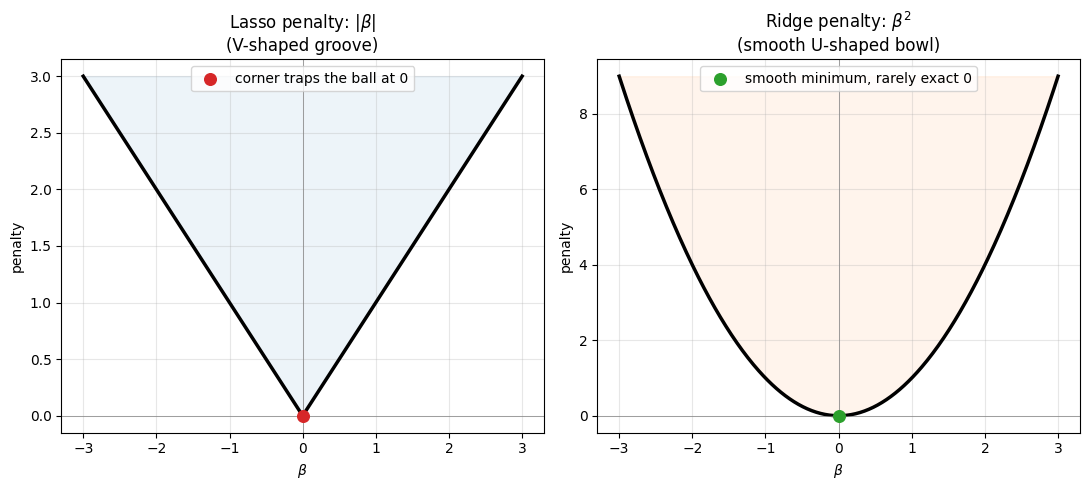

In [3]:

x = np.linspace(-3, 3, 400)
y_l1 = np.abs(x)
y_l2 = x**2
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
ax = axes[0]
ax.plot(x, y_l1, color="black", linewidth=2.5)
ax.scatter([0], [0], color="tab:red", zorder=5, s=70, label="corner traps the ball at 0")
ax.fill_between(x, y_l1, y_l1.max(), color="tab:blue", alpha=0.08)
ax.set_title(r"Lasso penalty: $|\beta|$" + "\n(V-shaped groove)")
ax.set_xlabel(r"$\beta$")
ax.set_ylabel("penalty")
ax.axhline(0, color="gray", linewidth=0.5)
ax.axvline(0, color="gray", linewidth=0.5)
ax.legend(loc="upper center")
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(x, y_l2, color="black", linewidth=2.5)
ax.scatter([0], [0], color="tab:green", zorder=5, s=70, label="smooth minimum, rarely exact 0")
ax.fill_between(x, y_l2, y_l2.max(), color="tab:orange", alpha=0.08)
ax.set_title(r"Ridge penalty: $\beta^2$" + "\n(smooth U-shaped bowl)")
ax.set_xlabel(r"$\beta$")
ax.set_ylabel("penalty")
ax.axhline(0, color="gray", linewidth=0.5)
ax.axvline(0, color="gray", linewidth=0.5)
ax.legend(loc="upper center")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Let's see Ridge on an example.

### Example

$n = 200$

$\text{Number of informative features} = 2$

$\text{Number of redundant features} = 1$


We expect Ridge to catch that redundant feature as well but penalize more mildly.


In [4]:
X, y = make_regression(
    n_samples=200,
    n_features=3,
    n_informative=2,
    random_state=38,
)
df = pd.DataFrame(X, columns=["x1", "x2", "x3"])
df["y"] = y

ridge = Ridge(random_state = 42, alpha = 1)
ridge.fit(df.drop(columns="y"), df["y"])
ridge_coef = ridge.coef_

print("x1 coefficient:", ridge_coef[0])
print("x2 coefficient:", ridge_coef[1])
print("x3 coefficient:", ridge_coef[2])

x1 coefficient: 73.443034586021
x2 coefficient: 37.328034325375114
x3 coefficient: -0.00367107508397972


### Notes

1. All linear models are sensitive to scale differences. We are using mock data, so we did not need to scale the variables. In real-world applications, we must check the scale of the predictors.
2. $\lambda$ selection may not be that easy. $\lambda$ directly reflects the penalization power. We don't want it to be too large or too small. For that purpose, we typically select $\lambda$ using cross-validation: we fit the model over a grid of $\lambda$ values and pick the one that minimizes the cross-validated error. This way, the choice of $\lambda$ is driven by the data itself, rather than by a manual guess.

## Using Regularized Models for Statistical Inference

Regularization has a downside. It makes statistical inference impractical. Consider the OLS solution:

$\hat{\beta} = (X^TX)^{-1}(X^Ty)$

Since the error terms are assumed to be normally distributed, $\hat{\beta}$ is also normally distributed, and unbiased (its expectation equals the true coefficient $\beta$). This is what allows us to report standard errors and p-values. There is no additional force pulling the estimated parameters away from their true values.

$\hat{\beta}$ in Ridge Regression is still normally distributed and has a closed form solution:

$\hat{\beta} = (X^TX + \lambda I)^{-1}X^Ty$


However, the regularization term forces all coefficients to shrink toward zero. For example, if the true coefficient is $\beta = 5$, even a perfect model would recover something like $\hat{\beta} = 4.5$ instead. This means $\hat{\beta}$ is systematically biased (its distribution is centered away from the true value) so the standard errors and p-values do not reflect the reality anymore.

In Lasso, things get even worse. Whether a coefficient lands exactly at 0 is a data dependent decision, and the selection step breaks $\hat{\beta}$'s normality. It is also nondifferentiable at zero. Therefore, we cannot find $\hat{\beta}$ analytically. Hence there is no standard error or p-value to report from the beginning.


We can overcome this problem by using "Debiased Lasso Algorithm". It is designed to correct the systematic shrinkage bias introduced by L1 regularization.

In [5]:
X, y = make_regression(
    n_samples=200,
    n_features=3,
    n_informative=2,
    random_state=38,
)

In [6]:
debiased_lasso = DebiasedLasso(random_state=42)

debiased_lasso.fit(X, y)
coef = debiased_lasso.coef_
se = debiased_lasso.coef_stderr_
z_scores = coef / se
p_values = 2 * (1 - stats.norm.cdf(np.abs(z_scores)))

alpha = 0.05
z_crit = stats.norm.ppf(1 - alpha / 2)
ci_lower = coef - z_crit * se
ci_upper = coef + z_crit * se

header = f"{'':<8}{'coef':>10}{'std err':>12}{'z':>10}{'P>|z|':>10}{'[0.025':>12}{'0.975]':>10}"
print("=" * len(header))
print(header)
print("-" * len(header))

for i in range(len(coef)):
    name = f"x{i+1}"
    print(f"{name:<8}{coef[i]:>10.4f}{se[i]:>12.4f}{z_scores[i]:>10.3f}"
          f"{p_values[i]:>10.3f}{ci_lower[i]:>12.4f}{ci_upper[i]:>10.4f}")

print("=" * len(header))

              coef     std err         z     P>|z|      [0.025    0.975]
------------------------------------------------------------------------
x1         73.8368      0.0071 10354.771     0.000     73.8228   73.8508
x2         37.4904      0.0065  5730.889     0.000     37.4776   37.5032
x3          0.0002      0.0064     0.032     0.974     -0.0124    0.0128
